# Deduplicating intersections: `block_size` vs `min_spacing`

When lines cross each other repeatedly in a small area (e.g. at very low angles, or with `proximity_dist`), `create_intersection_table` can return many near-duplicate crossovers. Two parameters thin them, keeping the best (lowest `max_dist`, preferring true intersections over proximity ones) intersection of each line pair per neighborhood:

- **`block_size`**: 2D spatial window — drops an intersection if a better one of the same line pair is within this *straight-line distance*.
- **`min_spacing`**: 1D along-line window — drops an intersection if a better one of the same line pair is within this distance **along both lines**.

The difference matters when a line doubles back (a "hairpin") and re-crosses another line: the two crossings are spatially close, but far apart along the hairpin line, so they constrain different parts of that line and are both worth keeping for levelling. `block_size` drops one of them; `min_spacing` keeps both.

If both parameters are passed, they act as one combined filter in a single pass: an intersection is dropped if it fails **either** test against an already-kept intersection.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import airbornegeo

## Synthetic survey

Three lines:
- **Line 1**: straight horizontal line.
- **Line 2**: a hairpin which crosses line 1 twice, only 400 m apart spatially, but ~6.4 km apart along line 2.
- **Line 3**: a wiggly low-angle line which grazes line 1, crossing it several times within a couple of kilometres — true duplicates we want to thin.

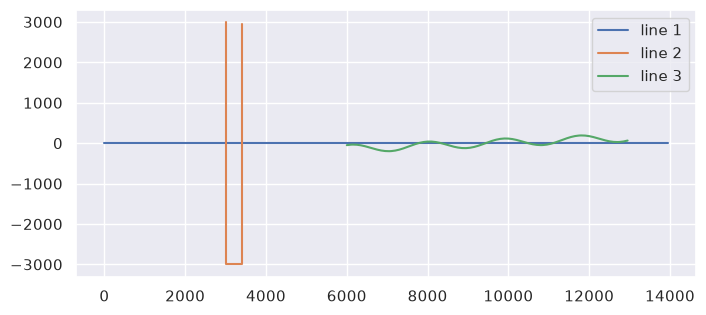

In [ ]:
# line 1: straight
xa = np.arange(0, 14000, 50.0)
line1 = pd.DataFrame({"easting": xa, "northing": 0.0, "line": 1})

# line 2: hairpin, down 6 km at x=3000, across 400 m, back up at x=3400
d = np.arange(0, 12400, 50.0)
line2 = pd.DataFrame(
    {
        "easting": np.where(
            d < 6000, 3000.0, np.where(d < 6400, 3000 + (d - 6000), 3400.0)
        ),
        "northing": np.where(
            d < 6000, 3000 - d, np.where(d < 6400, -3000.0, -3000 + (d - 6400))
        ),
        "line": 2,
    }
)

# line 3: low-angle graze of line 1 with a wiggle -> several crossings
xc = np.arange(6000, 13000, 50.0)
line3 = pd.DataFrame(
    {
        "easting": xc,
        "northing": 100 * np.sin(xc / 300) + 0.04 * (xc - 9500),
        "line": 3,
    }
)

data = pd.concat([line1, line2, line3], ignore_index=True)

_fig, ax = plt.subplots(figsize=(8, 5))
for name, df in data.groupby("line"):
    ax.plot(df.easting, df.northing, label=f"line {name}")
ax.legend()
ax.set_aspect("equal")

## No deduplication

Without either parameter we get all the crossings: 2 hairpin crossings (lines 1/2) and several graze crossings (lines 1/3).

,line1,line2,line1_along_dist,line2_along_dist,is_buffered,is_proximity,geometry,easting,northing,max_dist
0,1,2,3400.0,9400.000000,False,False,POINT (3400 0),3400.0,0.0,0.000000
1,1,2,3000.0,3000.000000,False,False,POINT (3000 0),3000.0,0.0,0.000000
2,1,3,11100.0,5229.406843,False,False,POINT (11100 0),11100.0,0.0,0.353813
3,1,3,7770.0,1819.487721,False,False,POINT (7770 0),7770.0,0.0,20.751231
4,1,3,8337.0,2394.109468,False,False,POINT (8337 0),8337.0,0.0,13.416142
5,1,3,10490.0,4610.119613,False,False,POINT (10490 0),10490.0,0.0,10.389544
6,1,3,9433.0,3522.542659,False,False,POINT (9433 0),9433.0,0.0,18.163901


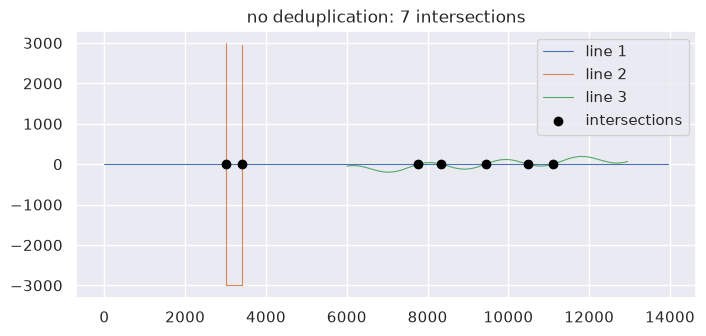

In [ ]:
def plot_inters(inters, title):
    _fig, ax = plt.subplots(figsize=(8, 5))
    for name, df in data.groupby("line"):
        ax.plot(df.easting, df.northing, lw=0.8, label=f"line {name}")
    ax.scatter(
        inters.easting,
        inters.northing,
        c="black",
        zorder=3,
        label="intersections",
    )
    ax.legend()
    ax.set_aspect("equal")
    ax.set_title(title)


inters = airbornegeo.create_intersection_table(
    data,
    line_column="line",
    method="network",
    progressbar=False,
)
plot_inters(inters, f"no deduplication: {len(inters)} intersections")
inters

## `block_size` only (2D)

A 1 km spatial window correctly thins the graze crossings, but also wrongly collapses the two hairpin crossings into one, since they are only 400 m apart spatially.

,line1,line2,line1_along_dist,line2_along_dist,is_buffered,is_proximity,geometry,easting,northing,max_dist
0,1,2,3400.0,9400.000000,False,False,POINT (3400 0),3400.0,0.0,0.000000
1,1,3,11100.0,5229.406843,False,False,POINT (11100 0),11100.0,0.0,0.353813
2,1,3,8337.0,2394.109468,False,False,POINT (8337 0),8337.0,0.0,13.416142
3,1,3,9433.0,3522.542659,False,False,POINT (9433 0),9433.0,0.0,18.163901


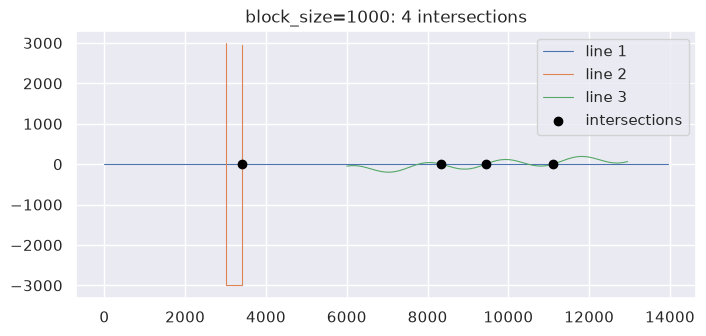

In [4]:
inters = airbornegeo.create_intersection_table(
    data,
    line_column="line",
    method="network",
    block_size=1000,
    progressbar=False,
)
plot_inters(inters, f"block_size=1000: {len(inters)} intersections")
inters

## `min_spacing` only (1D)

A 2 km along-line window thins the graze crossings (they are within 2 km of each other along both lines), but keeps **both** hairpin crossings, since they are ~6.4 km apart along line 2. The `line1_along_dist` / `line2_along_dist` columns show the distance along each line used for this test.

,line1,line2,line1_along_dist,line2_along_dist,is_buffered,is_proximity,geometry,easting,northing,max_dist
0,1,2,3400.0,9400.000000,False,False,POINT (3400 0),3400.0,0.0,0.000000
1,1,2,3000.0,3000.000000,False,False,POINT (3000 0),3000.0,0.0,0.000000
2,1,3,11100.0,5229.406843,False,False,POINT (11100 0),11100.0,0.0,0.353813
3,1,3,8337.0,2394.109468,False,False,POINT (8337 0),8337.0,0.0,13.416142


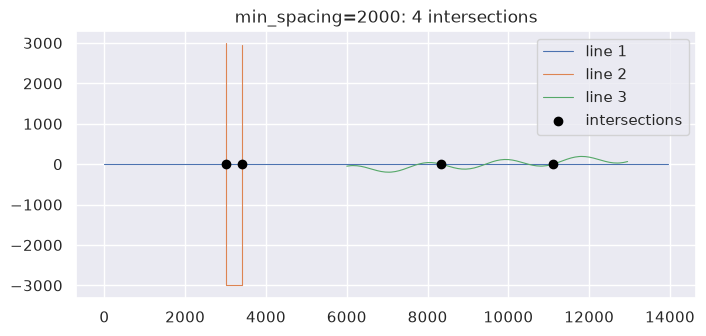

In [5]:
inters = airbornegeo.create_intersection_table(
    data,
    line_column="line",
    method="network",
    min_spacing=2000,
    progressbar=False,
)
plot_inters(inters, f"min_spacing=2000: {len(inters)} intersections")
inters

## Both together

The two act as a single combined filter: an intersection is dropped if it is within `block_size` spatially **or** within `min_spacing` along both lines of a better intersection. A small `block_size` (e.g. to catch numerically-duplicate points) combines naturally with a larger `min_spacing`. Note a `min_spacing` larger than `block_size` is typical, since along-line distance is always at least the straight-line distance.

,line1,line2,line1_along_dist,line2_along_dist,is_buffered,is_proximity,geometry,easting,northing,max_dist
0,1,2,3400.0,9400.000000,False,False,POINT (3400 0),3400.0,0.0,0.000000
1,1,2,3000.0,3000.000000,False,False,POINT (3000 0),3000.0,0.0,0.000000
2,1,3,11100.0,5229.406843,False,False,POINT (11100 0),11100.0,0.0,0.353813
3,1,3,8337.0,2394.109468,False,False,POINT (8337 0),8337.0,0.0,13.416142


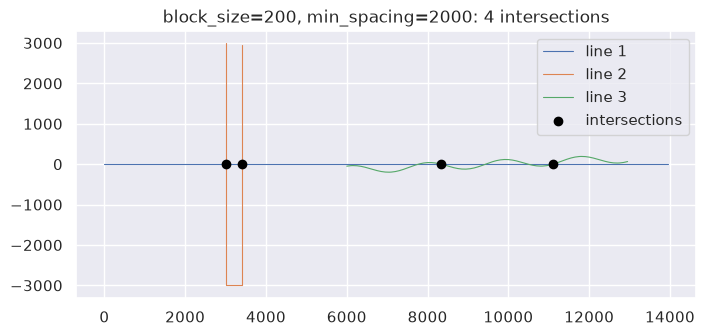

In [6]:
inters = airbornegeo.create_intersection_table(
    data,
    line_column="line",
    method="network",
    block_size=200,
    min_spacing=2000,
    progressbar=False,
)
plot_inters(inters, f"block_size=200, min_spacing=2000: {len(inters)} intersections")
inters

## Summary

- Use `block_size` when you want at most one crossover of a line pair per spatial neighborhood, regardless of line topology.
- Use `min_spacing` when crossovers should be thinned by how much *of each line* they constrain — it keeps spatially-close re-crossings (hairpins, loops) which are far apart along one of the lines.
- Passing both applies both criteria in one pass; an intersection must clear both to be kept.

Note that since distance along a line is always at least the straight-line distance, `min_spacing=s` only ever drops a subset of what `block_size=s` would drop — its value is that you can use a large `min_spacing` without collapsing genuinely distinct re-crossings.